In [1]:
import os
import glob
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt

ROI loaded. CRS: EPSG:32634


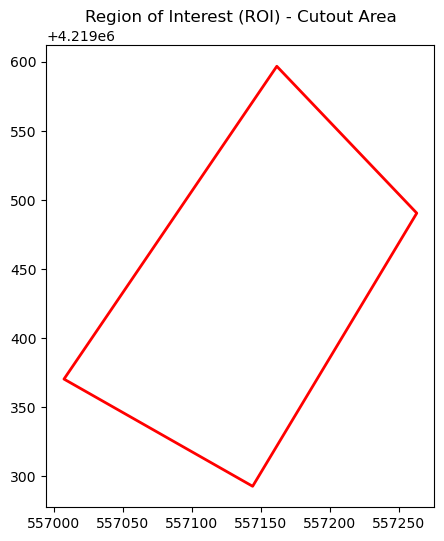

In [2]:
# 1. Pfade definieren (Bitte anpassen!)
input_folder = "/net/home/sloeblein/Wildfire/QGIS/Files/4_ML_Ready_Grids"  # Ordner mit den großen Original-TIFs
output_folder = "/net/home/sloeblein/Wildfire/QGIS/Files/5_Cropped_Images" # Ziel-Ordner
roi_path = "/net/home/sloeblein/Wildfire/QGIS/Files/5_Cropped_Images/roi_cutout.shp"

os.makedirs(output_folder, exist_ok=True)

# 2. ROI (Shapefile) laden
roi = gpd.read_file(roi_path)

print(f"ROI loaded. CRS: {roi.crs}")

# 3. ROI plotten
roi.plot(edgecolor="red", facecolor="none", linewidth=2, figsize=(8, 6))
plt.title("Region of Interest (ROI) - Cutout Area")
plt.show()

In [3]:
# 1. Alle TIF-Dateien finden
all_tifs = glob.glob(os.path.join(input_folder, "*.tif"))
print(f"Gefundene TIF-Dateien zum Zuschneiden: {len(all_tifs)}\n")

cropped_files_paths = [] # Speichern wir uns für den Plot am Ende

for file in all_tifs:
    basename = os.path.basename(file)
    print(f"Verarbeite: {basename}...")
    
    # A) Rasterbild laden
    ds = rxr.open_rasterio(file)
    
    # B) Koordinatensystem-Check!
    raster_crs = ds.rio.crs
    
    if roi.crs != raster_crs:
        print(f"  -> ⚠️ CRS Mismatch! Raster: {raster_crs} | ROI: {roi.crs}")
        print("  -> Transformiere Shapefile auf Raster-CRS...")
        roi_current = roi.to_crs(raster_crs)
    else:
        roi_current = roi
        
    # C) Zuschneiden (Clipping)
    try:
        ds_cropped = ds.rio.clip(roi_current.geometry, roi_current.crs, drop=True)
        
        # D) Speichern
        output_path = os.path.join(output_folder, basename.replace(".tif", "_cropped.tif"))
        ds_cropped.rio.to_raster(output_path)
        cropped_files_paths.append(output_path)
        print(f"  -> ✅ Erfolgreich zugeschnitten und gespeichert!\n")
        
    except Exception as e:
        print(f"  -> ❌ Fehler beim Zuschneiden von {basename}: {e}\n")
        
    finally:
        # RAM aufräumen
        ds.close()
        if 'ds_cropped' in locals():
            ds_cropped.close()

print("Alle Bilder wurden verarbeitet!")

Gefundene TIF-Dateien zum Zuschneiden: 5

Verarbeite: 251026_final_grid.tif...
  -> ✅ Erfolgreich zugeschnitten und gespeichert!

Verarbeite: 260222_final_grid.tif...
  -> ✅ Erfolgreich zugeschnitten und gespeichert!

Verarbeite: 250901_final_grid.tif...
  -> ✅ Erfolgreich zugeschnitten und gespeichert!

Verarbeite: 250821_final_grid.tif...
  -> ✅ Erfolgreich zugeschnitten und gespeichert!

Verarbeite: 260204_final_grid.tif...
  -> ✅ Erfolgreich zugeschnitten und gespeichert!

Alle Bilder wurden verarbeitet!


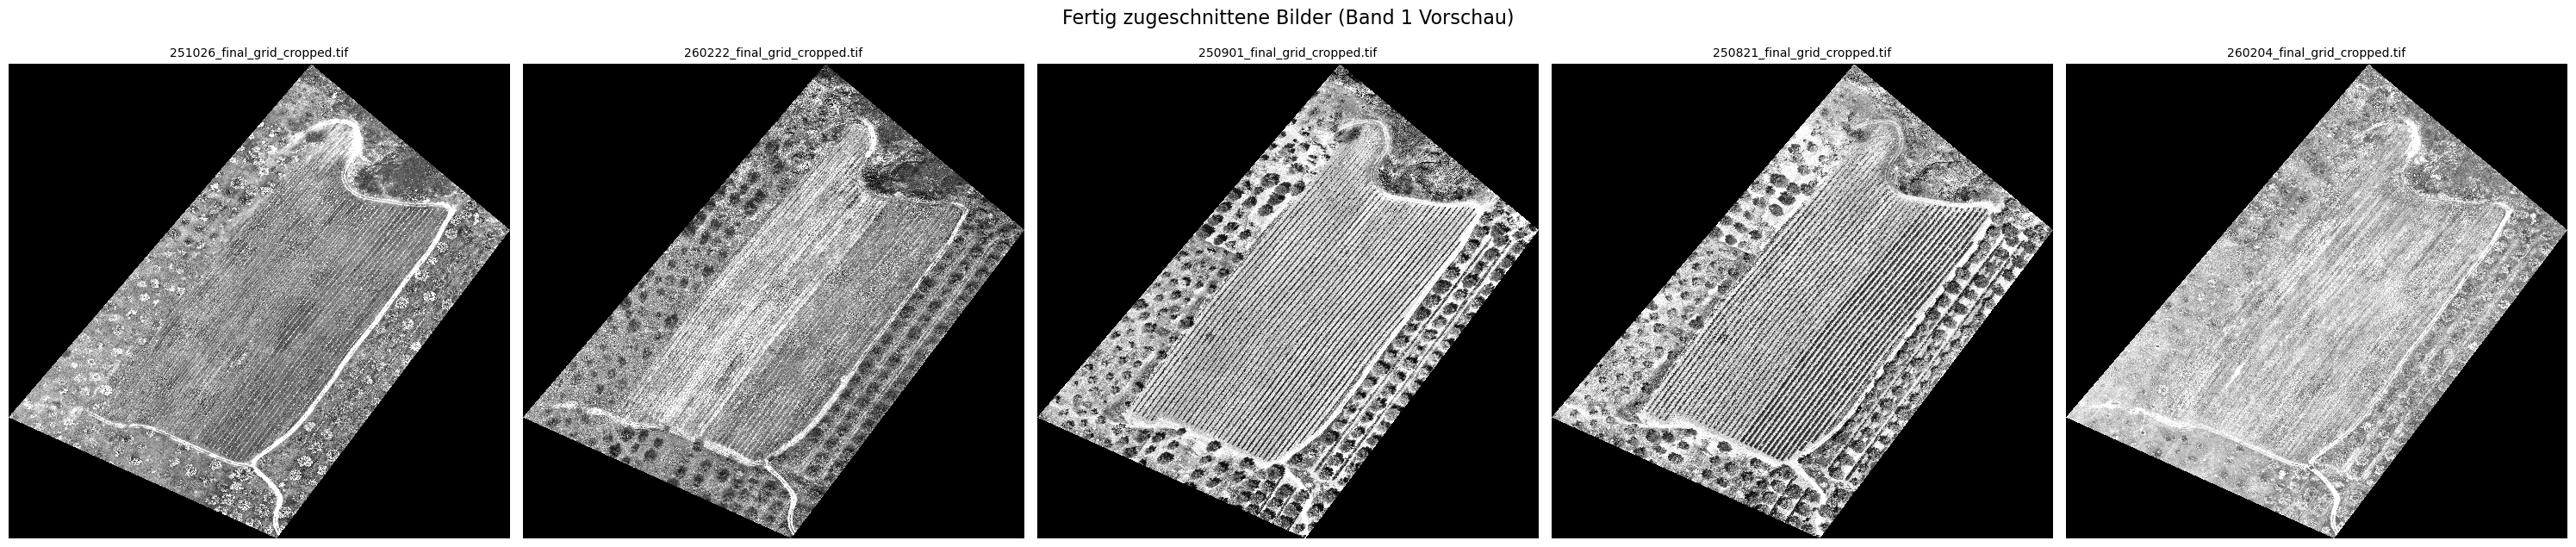

In [4]:
# Wir plotten bis zu 4 der zugeschnittenen Bilder als Kontrolle
num_plots = min(len(cropped_files_paths), 5)

if num_plots > 0:
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    
    # Falls es nur ein Bild ist, machen wir eine Liste aus axes, damit die Schleife funktioniert
    if num_plots == 1:
        axes = [axes]
        
    for i, path in enumerate(cropped_files_paths[:num_plots]):
        # Bild laden
        ds_plot = rxr.open_rasterio(path)
        
        # Wir plotten nur Band 1 (Rot), da das am einfachsten robust darzustellen ist
        # Falls du eine andere Visualisierung willst, kann man das anpassen.
        band1 = ds_plot.sel(band=1)
        
        # Plotten
        band1.plot(ax=axes[i], cmap='gray', robust=True, add_colorbar=False)
        axes[i].set_title(os.path.basename(path), fontsize=10)
        axes[i].axis("off")
        
        ds_plot.close()
        
    plt.tight_layout()
    plt.suptitle("Fertig zugeschnittene Bilder (Band 1 Vorschau)", fontsize=16, y=1.05)
    plt.show()
else:
    print("Keine zugeschnittenen Bilder zum Plotten gefunden.")